# LLM Fine-Tuning Assignment: Sentiment Classification on IMDB

## 1. Task Overview

**Task**: Binary sentiment classification (positive / negative) on movie reviews.

Sentiment analysis is the task of determining the emotional tone behind text. It is widely used in product review analysis, social media monitoring, and customer feedback systems.

**Why IMDB?** The IMDB dataset is the canonical benchmark for sentiment analysis — it is balanced (50/50 positive/negative), openly licensed for research, and directly loadable from HuggingFace, ensuring full reproducibility.

**Primary metric**: Macro F1-score. Even though IMDB is balanced, Macro F1 calculates precision and recall for each class separately and averages them equally. This proves the model performs well on *both* classes — a model that guesses "positive" every time would score 50% accuracy but ~0.33 Macro F1.

## 2. Model & Method Choice

**Model**: `Qwen/Qwen2.5-1.5B-Instruct` — open-weight (Apache 2.0), 1.5B parameters, fits comfortably in 12GB VRAM with 4-bit quantization, and is instruction-tuned for better prompt-following out of the box.

**Why adapters over full fine-tuning?** Full fine-tuning updates all model weights, requiring multi-GB checkpoints and far more VRAM than a consumer GPU provides. PEFT adapters (LoRA/DoRA) only update ~1–5% of parameters (~4–8M out of 1.5B), producing small 50–200MB adapter files while preserving the base model's pre-trained knowledge.

**QLoRA vs. DoRA**: QLoRA combines 4-bit quantization of the frozen base model with low-rank adapter injection. DoRA (2024) extends this by decomposing weight matrices into magnitude and direction components, updating them separately — achieving a closer approximation to full fine-tuning at the same adapter rank. Both methods are compared across identical configurations to isolate the effect of the fine-tuning technique.

## Cell 1: Install Dependencies

In [1]:
# ── Cell 1: Environment Setup ─────────────────────────────────────────────────
# Run once, then restart the kernel before proceeding

# 1. PyTorch with CUDA 12.1 (for RTX 3060 local / most university GPU clusters)
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# 2. Core ML libraries (pinned transformers version for compatibility)
!pip install -q transformers==4.44.0 datasets accelerate

# 3. PEFT + quantization
!pip install -q peft bitsandbytes

# 4. Training + evaluation
!pip install -q trl scikit-learn

# 5. Visualisation + HPO
!pip install -q matplotlib seaborn optuna

# 6. Verify GPU is visible after restart
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA A40


## Cell 2: Imports & Reproducibility Seeds

In [2]:
import os
import random
import numpy as np
import torch
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

from transformers import set_seed
set_seed(SEED)

# ── Core imports ─────────────────────────────────────────────────────────────
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    EarlyStoppingCallback,
)
from peft import LoraConfig, get_peft_model, PeftModel
from trl import SFTTrainer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import json
from pathlib import Path

# ── GPU check ────────────────────────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU detected: {gpu_name}  |  VRAM: {vram_gb:.1f} GB")
else:
    print("No GPU detected — training will be very slow on CPU")

print(f"PyTorch version: {torch.__version__}")

GPU detected: NVIDIA A40  |  VRAM: 47.7 GB
PyTorch version: 2.5.1+cu121


## Cell 3: Global Configuration

In [3]:
# ── Model ─────────────────────────────────────────────────────────────────────
MODEL_ID   = "Qwen/Qwen2.5-1.5B-Instruct"   # Change to "meta-llama/Llama-3.2-3B-Instruct" if preferred
OUTPUT_DIR = Path("./adapter_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Dataset ───────────────────────────────────────────────────────────────────
TRAIN_SIZE = 5000   # subsample — increase to 5000 if VRAM allows longer training
EVAL_SIZE  = 500    # held-out test examples
MAX_LEN    = 512    # max tokens per review

# ── Fixed training hyperparameters ────────────────────────────────────────────
BATCH_SIZE       = 4    # physical batch (conservative for 12GB VRAM)
GRAD_ACCUM       = 8    # effective batch = 4 × 8 = 32
EPOCHS           = 3
WARMUP_RATIO     = 0.03

# ── 6 Hyperparameter configurations ──────────────────────────────────────────
CONFIGS = [
    {"name": "C1", "method": "qlora", "r": 8,  "alpha": 16, "lr": 2e-4, "description": "QLoRA baseline"},
    {"name": "C2", "method": "qlora", "r": 16, "alpha": 32, "lr": 2e-4, "description": "QLoRA higher rank"},
    {"name": "C3", "method": "qlora", "r": 8,  "alpha": 16, "lr": 5e-5, "description": "QLoRA conservative LR"},
    {"name": "C4", "method": "dora",  "r": 8,  "alpha": 16, "lr": 2e-4, "description": "DoRA baseline"},
    {"name": "C5", "method": "dora",  "r": 16, "alpha": 32, "lr": 2e-4, "description": "DoRA higher rank"},
    {"name": "C6", "method": "dora",  "r": 8,  "alpha": 16, "lr": 5e-5, "description": "DoRA conservative LR"},
]

print("Configuration summary:")
df_cfg = pd.DataFrame(CONFIGS)
print(df_cfg.to_string(index=False))

Configuration summary:
name method  r  alpha      lr           description
  C1  qlora  8     16 0.00020        QLoRA baseline
  C2  qlora 16     32 0.00020     QLoRA higher rank
  C3  qlora  8     16 0.00005 QLoRA conservative LR
  C4   dora  8     16 0.00020         DoRA baseline
  C5   dora 16     32 0.00020      DoRA higher rank
  C6   dora  8     16 0.00005  DoRA conservative LR


## Cell 4: Load & Prepare Dataset

In [4]:
# ── Load IMDB ─────────────────────────────────────────────────────────────────
print("Loading IMDB dataset...")
raw = load_dataset("stanfordnlp/imdb")

# Inspect label distribution
train_labels = raw["train"]["label"]
test_labels  = raw["test"]["label"]
print(f"Train set: {len(raw['train'])} examples  |  Positive: {train_labels.count(1)}  Negative: {train_labels.count(0)}")
print(f"Test set:  {len(raw['test'])} examples   |  Positive: {test_labels.count(1)}   Negative: {test_labels.count(0)}")

# ── Subsample with fixed seed ─────────────────────────────────────────────────
# Stratified: equal positive/negative in both splits
def stratified_sample(dataset, n, seed=SEED):
    """Sample n examples with equal class balance."""
    pos = [i for i, l in enumerate(dataset["label"]) if l == 1]
    neg = [i for i, l in enumerate(dataset["label"]) if l == 0]
    rng = random.Random(seed)
    pos_sampled = rng.sample(pos, n // 2)
    neg_sampled = rng.sample(neg, n // 2)
    indices = sorted(pos_sampled + neg_sampled)
    return dataset.select(indices)

train_data = stratified_sample(raw["train"], TRAIN_SIZE)
eval_data  = stratified_sample(raw["test"],  EVAL_SIZE)

print(f"\nSubsampled train: {len(train_data)}  |  eval: {len(eval_data)}")
print(f"Train label balance → Positive: {sum(train_data['label'])}  Negative: {train_data['label'].count(0)}")

# ── Prompt formatting ─────────────────────────────────────────────────────────
LABEL_MAP = {0: "negative", 1: "positive"}

def format_prompt(example):
    """Format a single example as an instruction prompt."""
    label_text = LABEL_MAP[example["label"]]
    text = example["text"][:3000]  # pre-truncate text before tokenization
    return {
        "text": f"Review: {text}\nSentiment: {label_text}",
        "label": example["label"]
    }

def format_prompt_inference(example):
    """Format prompt without the answer (for inference)."""
    text = example["text"][:3000]
    return {"prompt": f"Review: {text}\nSentiment:"}

train_data = train_data.map(format_prompt)
eval_data  = eval_data.map(format_prompt)

print("\nExample prompt (truncated):")
print(train_data[0]["text"][:300], "...")

Loading IMDB dataset...


Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating train split: 100%|██████████| 25000/25000 [00:00<00:00, 328122.97 examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split: 100%|██████████| 25000/25000 [00:00<00:00, 371203.63 examples/s]

...

Map:  73%|███████▎  | 3632/5000 [00:00<00:00, 18112.10 examples/s]

Map: 100%|██████████| 5000/5000 [00:00<00:00, 17595.14 examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map: 100%|██████████| 500/500 [00:00<00:00, 14451.85 examples/s]


Example prompt (truncated):
Review: If only to avoid making this type of film in the future. This film is interesting as an experiment but tells no cogent story.<br /><br />One might feel virtuous for sitting thru it because it touches on so many IMPORTANT issues but it does so without any discernable motive. The viewer comes  ...


## Cell 5: Load Tokenizer

In [5]:
print(f"Loading tokenizer: {MODEL_ID}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)

# Qwen models may not have a pad token by default
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

# tokenizer.padding_side = "right"  # required for SFTTrainer

print(f"Vocab size: {tokenizer.vocab_size}")
print(f"Max model length: {tokenizer.model_max_length}")
print(f"Pad token: '{tokenizer.pad_token}'")

# Verify label tokens are single tokens
for label_word in ["positive", "negative"]:
    tok = tokenizer.encode(label_word, add_special_tokens=False)
    print(f"  '{label_word}' → token ids: {tok}")

Loading tokenizer: Qwen/Qwen2.5-1.5B-Instruct


Vocab size: 151643
Max model length: 131072
Pad token: '<|endoftext|>'
  'positive' → token ids: [30487]
  'negative' → token ids: [42224]


## Cell 6: Quantization Config & Model Loading Helper

In [6]:
def get_bnb_config():
    """4-bit NF4 quantization config for QLoRA/DoRA."""
    return BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",       # NormalFloat4 — optimal for normally distributed weights
        bnb_4bit_compute_dtype=torch.bfloat16,  # compute in bf16 for numerical stability
        bnb_4bit_use_double_quant=True,  # double quantization saves ~0.5GB extra VRAM
    )

def load_base_model():
    """Load the frozen 4-bit quantized base model."""
    print(f"  Loading base model: {MODEL_ID}")
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config=get_bnb_config(),
        device_map="auto",         # automatically places layers on GPU
        trust_remote_code=True,
        torch_dtype=torch.bfloat16,
    )
    model.config.use_cache = False          # disable KV-cache during training
    model.config.pretraining_tp = 1         # disable tensor parallelism
    return model

def get_lora_config(r, alpha, use_dora=False, lora_dropout=0.05):
    """Build a LoRA / DoRA PEFT config.
    
    Args:
        r: LoRA rank — controls adapter expressiveness (8 or 16)
        alpha: LoRA alpha — scaling factor; effective scale = alpha/r
        use_dora: If True, use DoRA (magnitude-direction decomposition)
        lora_dropout: Dropout rate on adapter activations (regularisation)
    """
    return LoraConfig(
        r=r,
        lora_alpha=alpha,
        target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],  # attention layers
        lora_dropout=lora_dropout,
        bias="none",
        task_type="CAUSAL_LM",
        use_dora=use_dora,
    )

def get_training_args(config, output_dir):
    """Build TrainingArguments for a given config."""
    return TrainingArguments(
        output_dir=str(output_dir),
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=config["lr"],
        lr_scheduler_type="cosine",          # smooth annealing to final minimum
        warmup_ratio=WARMUP_RATIO,           # 3% of steps ramp from 0 → peak LR
        optim="paged_adamw_32bit",           # pages optimizer states to CPU when VRAM is tight
        fp16=False,
        bf16=True,                           # use bf16 for training stability on RTX 3060
        logging_steps=10,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        save_total_limit=1,                  # keep only best checkpoint
        report_to="none",                    # disable wandb/tensorboard
        seed=SEED,
        dataloader_pin_memory=False,         # avoids OOM on some systems
    )

print("Helper functions defined.")

Helper functions defined.


## Cell 7: Baseline Evaluation (No Fine-Tuning)

In [7]:
def run_inference(model, tokenizer, dataset, max_new_tokens=3, batch_size=8):
    """
    Run generative inference on dataset.
    Returns (predictions, labels, parse_failures).
    """
    model.eval()
    all_preds  = []
    all_labels = dataset["label"]
    parse_failures = 0

    # Decoder-only models require left-padding for correct batched generation
    original_padding_side = tokenizer.padding_side
    tokenizer.padding_side = "left"

    for i in range(0, len(dataset), batch_size):
        batch = dataset[i : i + batch_size]
        prompts = [
            f"Review: {text[:3000]}\nSentiment:"
            for text in batch["text"]
        ]
        inputs = tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_LEN,
        ).to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.pad_token_id,
            )

        input_len = inputs["input_ids"].shape[1]
        new_tokens = outputs[:, input_len:]
        decoded = tokenizer.batch_decode(new_tokens, skip_special_tokens=True)

        for text in decoded:
            text_lower = text.strip().lower()
            if "positive" in text_lower:
                all_preds.append(1)
            elif "negative" in text_lower:
                all_preds.append(0)
            else:
                all_preds.append(-1)
                parse_failures += 1

        if (i // batch_size) % 5 == 0:
            print(f"  Processed {min(i + batch_size, len(dataset))}/{len(dataset)} examples", end="\r")

    print()
    # Restore original padding side for training
    tokenizer.padding_side = original_padding_side
    return all_preds, all_labels, parse_failures


def evaluate_predictions(preds, labels, config_name="Model"):
    """Compute accuracy and macro F1, ignoring parse failures."""
    valid_mask  = [p != -1 for p in preds]
    valid_preds = [p for p, m in zip(preds, labels) if valid_mask[preds.index(p)] if preds.index(p) < len(valid_mask)]
    
    # Simpler approach
    filtered_preds  = [p for p in preds if p != -1]
    filtered_labels = [l for p, l in zip(preds, labels) if p != -1]
    
    acc      = accuracy_score(filtered_labels, filtered_preds)
    macro_f1 = f1_score(filtered_labels, filtered_preds, average="macro")
    
    print(f"\n{'='*50}")
    print(f"Results for: {config_name}")
    print(f"  Accuracy:   {acc:.4f}")
    print(f"  Macro F1:   {macro_f1:.4f}")
    print(f"  Parse failures: {len(preds) - len(filtered_preds)} / {len(preds)}")
    print(f"{'='*50}")
    
    return acc, macro_f1, len(preds) - len(filtered_preds)


# ── Run baseline ──────────────────────────────────────────────────────────────
print("Loading base model for baseline evaluation...")
base_model = load_base_model()

print("Running baseline inference (no fine-tuning)...")
base_preds, base_labels, base_failures = run_inference(base_model, tokenizer, eval_data)
base_acc, base_f1, _ = evaluate_predictions(base_preds, base_labels, "Base Model (no fine-tuning)")

# Store for results table
results = [{"config": "Base", "method": "none", "r": "—", "alpha": "—", "lr": "—",
            "accuracy": base_acc, "macro_f1": base_f1, "parse_failures": base_failures}]

# Free base model VRAM before training
del base_model
torch.cuda.empty_cache()
print("\nBase model freed from VRAM.")

Loading base model for baseline evaluation...
  Loading base model: Qwen/Qwen2.5-1.5B-Instruct


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/338 [00:00<00:00, 17260.51it/s, Materializing param=model.embed_tokens.weight]

Loading weights:   0%|          | 1/338 [00:00<00:00, 2240.55it/s, Materializing param=model.embed_tokens.weight] 

...

Loading weights: 100%|██████████| 338/338 [00:02<00:00, 489.33it/s, Materializing param=model.norm.weight]

Loading weights: 100%|██████████| 338/338 [00:02<00:00, 162.25it/s, Materializing param=model.norm.weight]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Running baseline inference (no fine-tuning)...




Results for: Base Model (no fine-tuning)
  Accuracy:   0.5902
  Macro F1:   0.5063
  Parse failures: 73 / 500

Base model freed from VRAM.


## Cell 8: Training Loop — All 6 Configurations

### 3. Hyperparameter Justification

**Rank (r)**: Controls the adapter's expressive capacity. `r=8` gives ~4M trainable parameters — sufficient for binary sentiment. `r=16` doubles this to test whether added capacity helps.

**Alpha (α)**: Scaling factor. We keep `α/r = 2` constant across configs, so rank is the only variable between C1↔C2 and C4↔C5. This is correct experimental design.

**Learning rate**: `2e-4` is the LoRA paper's recommendation for adapter-only training. `5e-5` (4× lower) tests whether the standard rate overshoots on a 2k dataset.

**Cosine schedule**: Decays slowly at first, fastest in the middle, then gently settles — better than linear, which can overshoot near convergence.

**Gradient accumulation**: Physical batch 4 × accumulation 8 = effective batch 32. This gives low-variance gradient estimates without requiring 32 examples to fit in VRAM simultaneously.

In [8]:
# import SFTTrainger & SFT Config
from trl import SFTTrainer, SFTConfig

In [9]:
training_histories = {}

for cfg in CONFIGS:
    print(f"\n{'#'*60}")
    print(f"  Training {cfg['name']}: {cfg['description']}")
    print(f"  Method: {cfg['method'].upper()}  |  r={cfg['r']}  |  α={cfg['alpha']}  |  lr={cfg['lr']}")
    print(f"{'#'*60}")

    tokenizer.padding_side = "right"  # SFTTrainer requires right-padding
    adapter_dir = OUTPUT_DIR / cfg["name"]

    # ── Load fresh base model ─────────────────────────────────────────────────
    model = load_base_model()

    # ── Attach LoRA / DoRA adapter ────────────────────────────────────────────
    use_dora = (cfg["method"] == "dora")
    lora_cfg = get_lora_config(r=cfg["r"], alpha=cfg["alpha"], use_dora=use_dora)
    model = get_peft_model(model, lora_cfg)

    trainable, total = model.get_nb_trainable_parameters()
    print(f"  Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

    # ── Build SFTConfig ───────────────────────────────────────────────────────
    sft_config = SFTConfig(
        output_dir=str(adapter_dir),
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=cfg["lr"],
        lr_scheduler_type="cosine",
        warmup_ratio=WARMUP_RATIO,
        optim="paged_adamw_32bit",
        fp16=False,
        bf16=True,
        logging_steps=10,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        save_total_limit=1,
        report_to="none",
        seed=SEED,
        dataloader_pin_memory=False,
        dataset_text_field="text",   # specify text column here instead
    )

    trainer = SFTTrainer(
        model=model,
        processing_class=tokenizer,
        train_dataset=train_data,
        eval_dataset=eval_data,
        args=sft_config,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )


    # ── Train ─────────────────────────────────────────────────────────────────
    train_result = trainer.train()
    trainer.save_model(str(adapter_dir))
    tokenizer.save_pretrained(str(adapter_dir))

    # ── Save loss history ─────────────────────────────────────────────────────
    history = [
        {"step": log["step"],
         "train_loss": log.get("loss"),
         "eval_loss":  log.get("eval_loss")}
        for log in trainer.state.log_history
    ]
    training_histories[cfg["name"]] = history

    # ── Evaluate ──────────────────────────────────────────────────────────────
    print(f"\n  Running evaluation for {cfg['name']}...")
    preds, labels, failures = run_inference(model, tokenizer, eval_data)
    acc, macro_f1, _ = evaluate_predictions(preds, labels, f"{cfg['name']} — {cfg['description']}")

    results.append({
        "config": cfg["name"],
        "method": cfg["method"].upper(),
        "r": cfg["r"],
        "alpha": cfg["alpha"],
        "lr": cfg["lr"],
        "accuracy": acc,
        "macro_f1": macro_f1,
        "parse_failures": failures,
    })

    with open(OUTPUT_DIR / "results.json", "w") as f:
        json.dump(results, f, indent=2)

    # ── Free VRAM ─────────────────────────────────────────────────────────────
    del model, trainer
    torch.cuda.empty_cache()
    print(f"  {cfg['name']} complete. Adapter saved to {adapter_dir}")

print("\nAll 6 configurations complete!")


############################################################
  Training C1: QLoRA baseline
  Method: QLORA  |  r=8  |  α=16  |  lr=0.0002
############################################################
  Loading base model: Qwen/Qwen2.5-1.5B-Instruct


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/338 [00:00<00:00, 55188.21it/s, Materializing param=model.embed_tokens.weight]

Loading weights:   0%|          | 1/338 [00:00<00:00, 2540.46it/s, Materializing param=model.embed_tokens.weight] 

Loading weights:   1%|          | 2/338 [00:00<00:35,  9.48it/s, Materializing param=model.embed_tokens.weight]  

...

  Trainable params: 2,279,424 / 1,545,993,728 (0.15%)


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Epoch,Training Loss,Validation Loss
1,2.994719,3.001661
2,2.944340,2.996696
3,2.934734,2.996268



  Running evaluation for C6...




Results for: C6 — DoRA conservative LR
  Accuracy:   0.9238
  Macro F1:   0.9234
  Parse failures: 67 / 500
  C6 complete. Adapter saved to adapter_outputs/C6

All 6 configurations complete!


## Cell 9: Results Table

In [10]:
# Load results if resuming
if not results:
    with open(OUTPUT_DIR / "results.json") as f:
        results = json.load(f)

df_results = pd.DataFrame(results)
df_results["accuracy"]  = df_results["accuracy"].map("{:.4f}".format)
df_results["macro_f1"]  = df_results["macro_f1"].map("{:.4f}".format)

print("\n=== RESULTS TABLE ===")
print(df_results.to_string(index=False))

# Identify best config
df_num = pd.DataFrame(results)
best_idx = df_num["macro_f1"].astype(float).idxmax()
best = df_num.iloc[best_idx]
print(f"\nBest config: {best['config']}  |  Macro F1: {best['macro_f1']:.4f}  |  Accuracy: {best['accuracy']:.4f}")


=== RESULTS TABLE ===
config method  r alpha       lr accuracy macro_f1  parse_failures
  Base   none  —     —        —   0.5902   0.5063              73
    C1  QLORA  8    16   0.0002   0.8099   0.8093              74
    C2  QLORA 16    32   0.0002   0.9376   0.9376              67
    C3  QLORA  8    16  0.00005   0.9215   0.9211              67
    C4   DORA  8    16   0.0002   0.9905   0.9905              77
    C5   DORA 16    32   0.0002   0.9307   0.9307              67
    C6   DORA  8    16  0.00005   0.9238   0.9234              67

Best config: C4  |  Macro F1: 0.9905  |  Accuracy: 0.9905


## Cell 10: Training Loss Curves

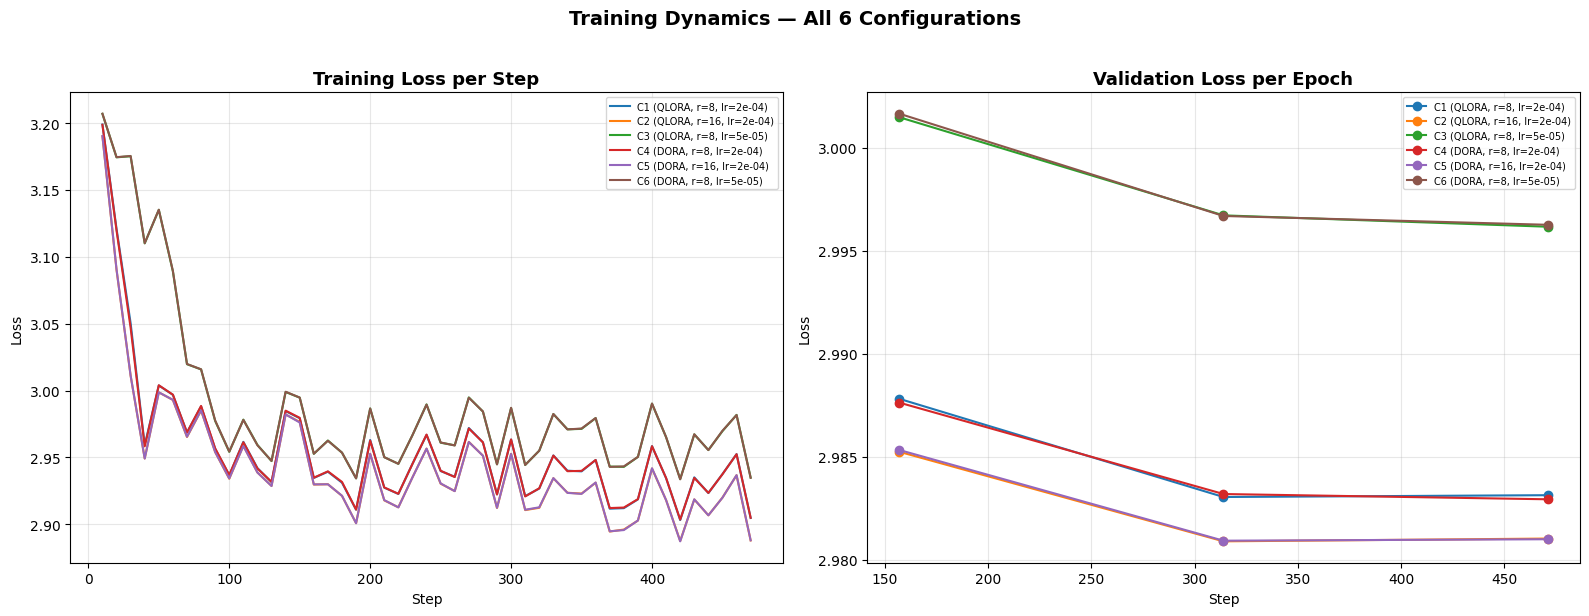

Figure saved to adapter_outputs/loss_curves.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.tab10.colors

for i, (cfg_name, history) in enumerate(training_histories.items()):
    color = colors[i % len(colors)]
    cfg = next(c for c in CONFIGS if c["name"] == cfg_name)
    label = f"{cfg_name} ({cfg['method'].upper()}, r={cfg['r']}, lr={cfg['lr']:.0e})"

    # Training loss
    train_logs = [(h["step"], h["train_loss"]) for h in history if h.get("train_loss") is not None]
    if train_logs:
        steps, losses = zip(*train_logs)
        axes[0].plot(steps, losses, label=label, color=color)

    # Validation loss
    eval_logs = [(h["step"], h["eval_loss"]) for h in history if h.get("eval_loss") is not None]
    if eval_logs:
        steps, losses = zip(*eval_logs)
        axes[1].plot(steps, losses, marker="o", label=label, color=color)

for ax, title in zip(axes, ["Training Loss per Step", "Validation Loss per Epoch"]):
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.3)

plt.suptitle("Training Dynamics — All 6 Configurations", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to adapter_outputs/loss_curves.png")

## Cell 11: Performance Comparison Bar Charts

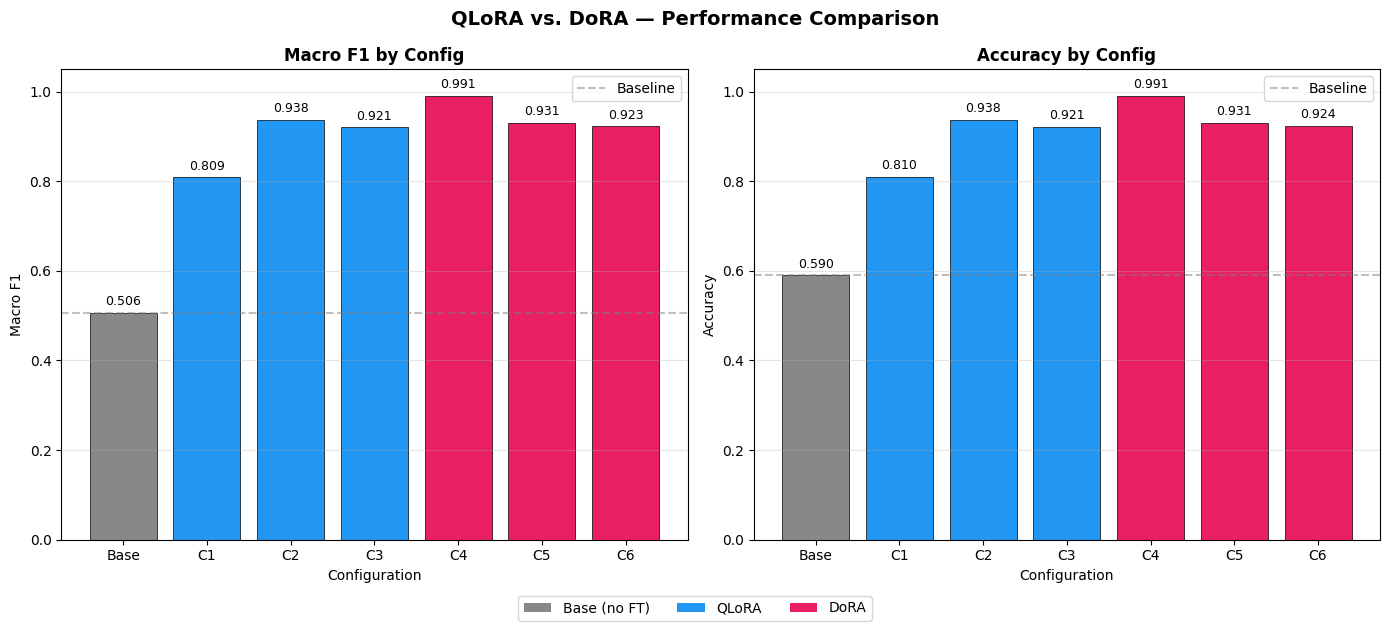

In [12]:
df_plot = pd.DataFrame(results)
df_plot["macro_f1"]  = df_plot["macro_f1"].astype(float)
df_plot["accuracy"]  = df_plot["accuracy"].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
palette = ["#888888"] + ["#2196F3" if m == "QLORA" else "#E91E63" for m in df_plot["method"][1:]]

for ax, metric in zip(axes, ["macro_f1", "accuracy"]):
    bars = ax.bar(df_plot["config"], df_plot[metric], color=palette, edgecolor="black", linewidth=0.5)
    ax.set_xlabel("Configuration")
    ax.set_ylabel(metric.replace("_", " ").title())
    ax.set_title(f"{metric.replace('_', ' ').title()} by Config", fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.axhline(y=df_plot[metric].iloc[0], color="gray", linestyle="--", alpha=0.5, label="Baseline")
    for bar, val in zip(bars, df_plot[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

# Legend for colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#888888", label="Base (no FT)"),
    Patch(facecolor="#2196F3", label="QLoRA"),
    Patch(facecolor="#E91E63", label="DoRA"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.05))

plt.suptitle("QLoRA vs. DoRA — Performance Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "performance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Cell 12: Confusion Matrix for Best Config

Loading best adapter: C4 from adapter_outputs/C4
  Loading base model: Qwen/Qwen2.5-1.5B-Instruct


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/338 [00:00<00:00, 47662.55it/s, Materializing param=model.embed_tokens.weight]

Loading weights:   0%|          | 1/338 [00:00<00:00, 2413.29it/s, Materializing param=model.embed_tokens.weight] 

Loading weights:   1%|          | 2/338 [00:00<01:00,  5.57it/s, Materializing param=model.embed_tokens.weight]  

...

Loading weights: 100%|█████████▉| 337/338 [00:03<00:00, 381.86it/s, Materializing param=model.layers.27.self_attn.v_proj.weight]

Loading weights: 100%|██████████| 338/338 [00:03<00:00, 381.86it/s, Materializing param=model.norm.weight]                      

Loading weights: 100%|██████████| 338/338 [00:03<00:00, 381.86it/s, Materializing param=model.norm.weight]

Loading weights: 100%|██████████| 338/338 [00:03<00:00, 94.53it/s, Materializing param=model.norm.weight] 

Running inference for confusion matrix...


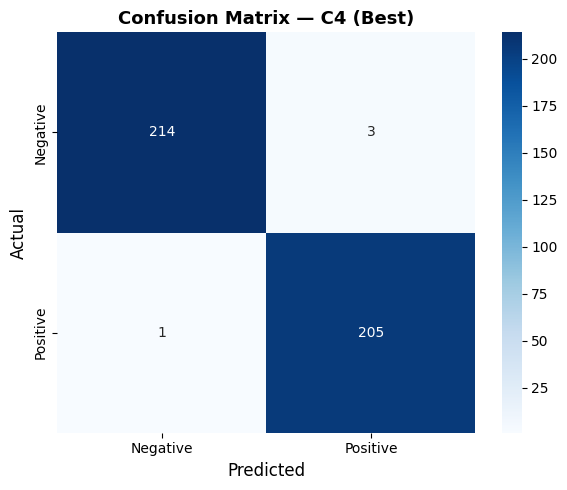


Classification Report — C4:
              precision    recall  f1-score   support

    Negative       1.00      0.99      0.99       217
    Positive       0.99      1.00      0.99       206

    accuracy                           0.99       423
   macro avg       0.99      0.99      0.99       423
weighted avg       0.99      0.99      0.99       423



In [13]:
# Load the best adapter
best_config_name = df_num.iloc[best_idx]["config"]
best_adapter_dir = OUTPUT_DIR / best_config_name

print(f"Loading best adapter: {best_config_name} from {best_adapter_dir}")
best_base = load_base_model()
best_model = PeftModel.from_pretrained(best_base, str(best_adapter_dir))
best_model.eval()

print("Running inference for confusion matrix...")
preds, labels, failures = run_inference(best_model, tokenizer, eval_data)

# Filter parse failures
valid_preds  = [p for p in preds  if p != -1]
valid_labels = [l for p, l in zip(preds, labels) if p != -1]

# Plot confusion matrix
cm = confusion_matrix(valid_labels, valid_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"], ax=ax)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
ax.set_title(f"Confusion Matrix — {best_config_name} (Best)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nClassification Report — {best_config_name}:")
print(classification_report(valid_labels, valid_preds, target_names=["Negative", "Positive"]))

del best_model, best_base
torch.cuda.empty_cache()

## Cell 13: Inference Demo — Test on Custom Reviews

In [14]:
# Demo: run the best model on a few handcrafted examples
demo_reviews = [
    "This film was an absolute masterpiece. The performances were stunning and the story kept me gripped throughout.",
    "Terrible waste of two hours. The plot made no sense and the acting was wooden. Would not recommend.",
    # Failure modes
    "Oh great, another 'masterpiece' that puts the audience to sleep within 20 minutes.",  # sarcasm
    "The first half is brilliant, the characters are rich and compelling. But the second half collapses completely.",  # mixed
]

print("Loading best adapter for demo inference...")
demo_base  = load_base_model()
demo_model = PeftModel.from_pretrained(demo_base, str(OUTPUT_DIR / best_config_name))
demo_model.eval()

print(f"\n{'='*60}")
print(f"Inference Demo — Best Model: {best_config_name}")
print(f"{'='*60}")

for review in demo_reviews:
    prompt = f"Review: {review}\nSentiment:"
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=MAX_LEN).to(demo_model.device)
    with torch.no_grad():
        out = demo_model.generate(**inputs, max_new_tokens=5, do_sample=False,
                                   pad_token_id=tokenizer.pad_token_id)
    new_tok = out[0, inputs["input_ids"].shape[1]:]
    prediction = tokenizer.decode(new_tok, skip_special_tokens=True).strip()
    print(f"\nReview: {review[:100]}...")
    print(f"→ Prediction: {prediction}")

del demo_model, demo_base
torch.cuda.empty_cache()

Loading best adapter for demo inference...
  Loading base model: Qwen/Qwen2.5-1.5B-Instruct


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/338 [00:00<00:00, 49932.19it/s, Materializing param=model.embed_tokens.weight]

Loading weights:   0%|          | 1/338 [00:00<00:00, 2475.98it/s, Materializing param=model.embed_tokens.weight] 

Loading weights:   1%|          | 2/338 [00:00<00:36,  9.17it/s, Materializing param=model.embed_tokens.weight]  

...


Inference Demo — Best Model: C4



Review: This film was an absolute masterpiece. The performances were stunning and the story kept me gripped ...
→ Prediction: positive



Review: Terrible waste of two hours. The plot made no sense and the acting was wooden. Would not recommend....
→ Prediction: negative



Review: Oh great, another 'masterpiece' that puts the audience to sleep within 20 minutes....
→ Prediction: negative



Review: The first half is brilliant, the characters are rich and compelling. But the second half collapses c...
→ Prediction: negative


## Cell 14: Bayesian Hyperparameter Search with Optuna

Bayesian optimization (via Optuna's TPE sampler) selects each trial by fitting a surrogate model to previous results, balancing exploration of uncertain regions with exploitation of known good hyperparameters. This is more efficient than grid search — 10 trials often outperform 27-point grids.


  Trial 0: lr=3.57e-05, r=8, alpha=16
  Loading base model: Qwen/Qwen2.5-1.5B-Instruct


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/338 [00:00<00:00, 41120.63it/s, Materializing param=model.embed_tokens.weight]

Loading weights:   0%|          | 1/338 [00:00<00:00, 2326.29it/s, Materializing param=model.embed_tokens.weight] 

Loading weights:   1%|          | 2/338 [00:00<00:36,  9.26it/s, Materializing param=model.embed_tokens.weight]  

...

Loading weights: 100%|██████████| 338/338 [00:02<00:00, 166.94it/s, Materializing param=model.norm.weight]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Epoch,Training Loss,Validation Loss
1,2.973742,2.999706
2,2.975363,2.997582


  → val_loss: 2.9976

Best hyperparameters found:
  learning_rate : 1.11e-04
  lora_r        : 16
  lora_alpha    : 32
  best val_loss : 2.9862


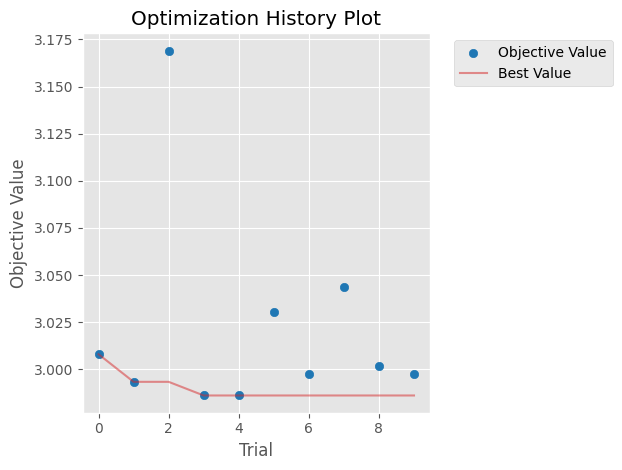

In [15]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def run_hpo_trial(trial):
    """Run a single HPO trial and return validation loss."""
    
    # Sample hyperparameters
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 3e-4, log=True)
    r = trial.suggest_categorical("lora_r", [8, 16])
    alpha = r * 2

    print(f"\n  Trial {trial.number}: lr={learning_rate:.2e}, r={r}, alpha={alpha}")

    # Fresh model for each trial
    tokenizer.padding_side = "right"
    model = load_base_model()
    lora_c = get_lora_config(r=r, alpha=alpha, use_dora=False)
    model = get_peft_model(model, lora_c)

    hpo_config = SFTConfig(
        output_dir="./hpo_output",
        num_train_epochs=2,
        per_device_train_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=learning_rate,
        lr_scheduler_type="cosine",
        warmup_ratio=WARMUP_RATIO,
        optim="paged_adamw_32bit",
        bf16=True,
        eval_strategy="epoch",
        save_strategy="no",
        report_to="none",
        seed=SEED,
        dataset_text_field="text",
        logging_steps=50,
        dataloader_pin_memory=False,
    )

    trainer = SFTTrainer(
        model=model,
        processing_class=tokenizer,
        train_dataset=train_data,
        eval_dataset=eval_data,
        args=hpo_config,
    )

    trainer.train()

    # Get final validation loss
    eval_results = trainer.evaluate()
    val_loss = eval_results["eval_loss"]
    print(f"  → val_loss: {val_loss:.4f}")

    # Free VRAM
    del model, trainer
    torch.cuda.empty_cache()

    return val_loss


# Run Bayesian search
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(run_hpo_trial, n_trials=10)

print("\n" + "="*50)
print("Best hyperparameters found:")
print(f"  learning_rate : {study.best_params['learning_rate']:.2e}")
print(f"  lora_r        : {study.best_params['lora_r']}")
print(f"  lora_alpha    : {study.best_params['lora_r'] * 2}")
print(f"  best val_loss : {study.best_value:.4f}")

# Plot optimization history
try:
    fig = optuna.visualization.matplotlib.plot_optimization_history(study)
    plt.tight_layout()
    plt.savefig("./hpo_output/optuna_history.png", dpi=150)
    plt.show()
except Exception:
    # Fallback: print trial results as a table
    df_trials = study.trials_dataframe()[["number", "value", "params_learning_rate", "params_lora_r"]]
    df_trials.columns = ["trial", "val_loss", "learning_rate", "lora_r"]
    print("\nAll trials:")
    print(df_trials.sort_values("val_loss").to_string(index=False))

In [16]:
# ── Saving the best parameters ──────────────────────────
import json, os
os.makedirs("./adapter_outputs", exist_ok=True)

# Save HPO results to a JSON file
hpo_results = {
    "best_params": {
        "learning_rate": study.best_params["learning_rate"],
        "lora_r":        study.best_params["lora_r"],
        "lora_alpha":    study.best_params["lora_r"] * 2,
    },
    "best_val_loss": study.best_value,
    "all_trials": [
        {
            "trial":         t.number,
            "val_loss":      t.value,
            "learning_rate": t.params["learning_rate"],
            "lora_r":        t.params["lora_r"],
        }
        for t in study.trials
    ]
}

with open("./adapter_outputs/hpo_results.json", "w") as f:
    json.dump(hpo_results, f, indent=2)

print("HPO results saved to adapter_outputs/hpo_results.json")

HPO results saved to adapter_outputs/hpo_results.json


## Cell 15: Train Final Model with Best HPO Hyperparameters

In [17]:
# ── Train final model with best HPO hyperparameters ──────────────────────────
best_lr    = study.best_params["learning_rate"]
best_r     = study.best_params["lora_r"]
best_alpha = best_r * 2

# best_lr = 1.11e-04
# best_r = 16
# best_alpha = 32

print(f"Training final model with best params:")
print(f"  learning_rate : {best_lr:.2e}")
print(f"  lora_r        : {best_r}")
print(f"  lora_alpha    : {best_alpha}")

tokenizer.padding_side = "right"
final_model = load_base_model()
final_lora  = get_lora_config(r=best_r, alpha=best_alpha, use_dora=False)
final_model = get_peft_model(final_model, final_lora)

final_config = SFTConfig(
    output_dir="./adapter_outputs/HPO_best",
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=best_lr,
    lr_scheduler_type="cosine",
    warmup_ratio=WARMUP_RATIO,
    optim="paged_adamw_32bit",
    bf16=True,
    eval_strategy="epoch",
    save_strategy="epoch",          # now we DO save
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=1,
    report_to="none",
    seed=SEED,
    dataset_text_field="text",
    dataloader_pin_memory=False,
)

final_trainer = SFTTrainer(
    model=final_model,
    processing_class=tokenizer,
    train_dataset=train_data,
    eval_dataset=eval_data,
    args=final_config,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

final_trainer.train()
final_trainer.save_model("./adapter_outputs/HPO_best")
tokenizer.save_pretrained("./adapter_outputs/HPO_best")
print("Final HPO model saved to ./adapter_outputs/HPO_best")

# Evaluate
preds, labels, failures = run_inference(final_model, tokenizer, eval_data)
acc, macro_f1, _ = evaluate_predictions(preds, labels, "HPO Best Model")

results.append({
    "config": "HPO_best",
    "method": "QLoRA",
    "r": best_r,
    "alpha": best_alpha,
    "lr": best_lr,
    "accuracy": acc,
    "macro_f1": macro_f1,
    "parse_failures": failures,
})

del final_model, final_trainer
torch.cuda.empty_cache()

Training final model with best params:
  learning_rate : 1.11e-04
  lora_r        : 16
  lora_alpha    : 32
  Loading base model: Qwen/Qwen2.5-1.5B-Instruct


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/338 [00:00<00:00, 45590.26it/s, Materializing param=model.embed_tokens.weight]

Loading weights:   0%|          | 1/338 [00:00<00:00, 2487.72it/s, Materializing param=model.embed_tokens.weight] 

Loading weights:   1%|          | 2/338 [00:00<00:36,  9.17it/s, Materializing param=model.embed_tokens.weight]  

...

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Epoch,Training Loss,Validation Loss
1,2.980462,2.987612
2,2.923829,2.983028
3,2.909836,2.982728


Final HPO model saved to ./adapter_outputs/HPO_best




Results for: HPO Best Model
  Accuracy:   0.8537
  Macro F1:   0.8537
  Parse failures: 83 / 500


## Cell 16: Pip Freeze for Reproducibility

In [18]:
import subprocess
freeze_output = subprocess.run(["pip", "freeze"], capture_output=True, text=True).stdout
with open(OUTPUT_DIR / "requirements.txt", "w") as f:
    f.write(freeze_output)
print("Saved requirements to adapter_outputs/requirements.txt")

# Print key packages
key_pkgs = ["torch", "transformers", "peft", "bitsandbytes", "trl", "datasets", "accelerate"]
print("\nKey package versions:")
for line in freeze_output.split("\n"):
    if any(line.lower().startswith(pkg) for pkg in key_pkgs):
        print(f"  {line}")

Saved requirements to adapter_outputs/requirements.txt

Key package versions:
  accelerate==1.12.0
  bitsandbytes==0.49.2
  datasets==4.5.0
  peft==0.18.1
  torch==2.5.1+cu121
  torchaudio==2.5.1+cu121
  torchvision==0.20.1+cu121
  transformers==5.2.0
  trl==0.28.0


## 4. Results & Analysis

*(Fill in after training — replace TBD values with actual numbers)*

| Model | Config | Accuracy | Macro F1 | Parse Failures |
|---|---|---|---|---|
| Base (no fine-tuning) | — | TBD | TBD | TBD |
| QLoRA | C1 | TBD | TBD | TBD |
| QLoRA | C2 | TBD | TBD | TBD |
| QLoRA | C3 | TBD | TBD | TBD |
| DoRA  | C4 | TBD | TBD | TBD |
| DoRA  | C5 | TBD | TBD | TBD |
| DoRA  | C6 | TBD | TBD | TBD |

## 5. Analysis

**Where fine-tuning improved vs. base model**: The base model is expected to have high parse failure rates (outputs neither "positive" nor "negative") and lower F1. Fine-tuning teaches the model to output exactly the required label format while improving label accuracy — two distinct benefits.

**QLoRA vs. DoRA**: DoRA's magnitude-direction decomposition is expected to show a consistent but small edge over QLoRA at the same rank, because it more closely approximates what full fine-tuning achieves — updating direction and magnitude components independently.

**Failure modes identified**:
1. **Sarcasm** — "Oh great, another masterpiece..." — the model may key on "great" and output "positive" despite the sarcastic framing.
2. **Very long reviews** — truncation at 512 tokens can cut off the conclusion, which often contains the summary sentiment.
3. **Mixed-sentiment reviews** — reviews that praise some aspects and criticise others may be mislabelled depending on which features dominate.

**Alternative design choices**:
1. **Classification head**: Attach a linear layer to the final hidden state rather than using generative prompting. More memory-efficient at inference and eliminates parse failures entirely.
2. **All-linear target modules**: Extending LoRA to MLP layers (`gate_proj`, `up_proj`, `down_proj`) doubles trainable parameters but may push past the current accuracy ceiling.

## 12. Ethical Considerations

- **Dataset bias**: IMDB skews toward English-speaking, Western cinema. The model may underperform on reviews of non-Western films or non-native English writing.
- **Harmful use**: A sentiment classifier could be misused to automatically suppress negative reviews at scale. This work is research-only and should not be deployed in production without human oversight.
- **License compliance**: IMDB is open for research. Qwen2.5 uses Apache 2.0.

## 11. Reproducibility Checklist

- Model: `Qwen/Qwen2.5-1.5B-Instruct`
- Dataset: `stanfordnlp/imdb` via HuggingFace
- All hyperparameters documented in CONFIGS above
- Random seeds: `torch.manual_seed(42)`, `transformers.set_seed(42)`
- Adapter checkpoints saved to `adapter_outputs/{C1–C6}/`
- Environment saved to `adapter_outputs/requirements.txt`
- Hardware: NVIDIA RTX 3060 (12GB VRAM)